# Statistical Concepts in Quantitative Finance
## A Beginner's Guide

Welcome! This notebook teaches you the most important statistical concepts in quantitative finance — **no prior finance or statistics knowledge required**.

Every section follows this pattern:
1. **Plain-English intuition** — what the concept *means* in the real world before any formula
2. **The math** — once you have the intuition, the formula is just a shortcut
3. **Code + charts** — see the concept come alive with real simulated data
4. **Why practitioners use it** — concrete examples from hedge funds, banks, and trading desks

### What you'll learn

| Section | Concept | One-line summary |
|---------|---------|-----------------|
| 1 | Setup | Generate realistic stock price data |
| 2 | Descriptive Statistics | Summarize return distributions (mean, std, skew) |
| 3 | Normality Tests | Are returns actually bell-shaped? |
| 4 | Rolling Volatility | How risk changes through time |
| **5** | **Variance vs Covariance** | **How individual and joint risk are measured** |
| 6 | Correlation | Normalized relationship between two assets |
| 7 | Value at Risk | How bad can losses get on a bad day? |
| 8 | Beta & CAPM | Systematic vs. idiosyncratic risk |
| 9 | Time Series Analysis | Detecting trends and autocorrelation |
| 10 | Monte Carlo Simulation | Forecasting distributions of future outcomes |

> **Tip for beginners:** Don't skip the grey explanation boxes — they're the most important part. The code is just how we *compute* the concept; the explanation is *what it means*.

## 1. Import Required Libraries

Import essential libraries for data manipulation, visualization, statistical analysis, and financial calculations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, jarque_bera, norm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Generate Mock Financial Data

Generate realistic mock price series for multiple assets using geometric Brownian motion. This simulates stock behavior with defined drift and volatility.

### Why Do We Need Mock Financial Data?

**The Core Problem:** Real market data has survivorship bias, look-ahead bias, and limited history. Backtesting on real data once "trains" your strategy to that period.

**Practical Examples:**
- **Hedge Fund Strategy Development**: Before deploying capital, quants generate thousands of synthetic price paths to test if a strategy survives diverse market regimes — bull, bear, and sideways.
- **Stress Testing Regulatory Compliance**: Under Basel III/IV, banks must prove solvency under extreme market scenarios. Simulated data creates conditions that rarely occur in history (e.g., simultaneous 30% crashes across all asset classes).
- **Risk Model Calibration**: An options desk generates GBM paths to calibrate Black-Scholes parameters σ and μ, then compares model prices against observed market prices to test accuracy.
- **Pair Trading Signal Validation**: Generating correlated mock assets lets researchers isolate whether a co-integration signal is statistically robust or an artifact of a specific data period.

**Geometric Brownian Motion Formula:**
$$S_t = S_0 \exp\left(\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right)$$

Where μ is drift, σ is volatility, and W_t is a Wiener process. This is the same model underpinning Black-Scholes option pricing.

In [2]:
# Generate mock financial data
n_days = 252  # Trading days in a year
n_assets = 4

# Asset parameters (drift, volatility)
assets = {
    'STOCK_A': {'S0': 100, 'mu': 0.10, 'sigma': 0.15},
    'STOCK_B': {'S0': 50, 'mu': 0.08, 'sigma': 0.20},
    'STOCK_C': {'S0': 200, 'mu': 0.12, 'sigma': 0.18},
    'MARKET_INDEX': {'S0': 100, 'mu': 0.09, 'sigma': 0.12}  # Market proxy
}

# Generate price paths using GBM
def generate_gbm_prices(S0, mu, sigma, n_days):
    dt = 1/252  # Daily
    returns = np.random.normal(mu * dt, sigma * np.sqrt(dt), n_days)
    prices = S0 * np.exp(np.cumsum(returns))
    return np.concatenate([[S0], prices])

prices = {}
for asset, params in assets.items():
    prices[asset] = generate_gbm_prices(params['S0'], params['mu'], params['sigma'], n_days)

# Create DataFrame
date_range = pd.date_range(start='2023-01-01', periods=len(prices['STOCK_A']), freq='D')
df_prices = pd.DataFrame(prices, index=date_range)
df_prices.index.name = 'Date'

print("Mock Financial Data (first 5 rows):")
print(df_prices.head())
print(f"\nData shape: {df_prices.shape}")

# Calculate daily percentage returns
df_returns = df_prices.pct_change().dropna()
print("\nDaily Returns (first 5 rows):")
print(df_returns.head())

Mock Financial Data (first 5 rows):
               STOCK_A    STOCK_B     STOCK_C  MARKET_INDEX
Date                                                       
2023-01-01  100.000000  50.000000  200.000000    100.000000
2023-01-02  100.510331  51.371170  198.624471    100.409464
2023-01-03  100.418943  52.060287  197.624481    100.585774
2023-01-04  101.075501  51.089430  196.394962     99.970926
2023-01-05  102.581323  50.794816  194.572959    100.537460

Data shape: (253, 4)

Daily Returns (first 5 rows):
             STOCK_A   STOCK_B   STOCK_C  MARKET_INDEX
Date                                                  
2023-01-02  0.005103  0.027423 -0.006878      0.004095
2023-01-03 -0.000909  0.013414 -0.005035      0.001756
2023-01-04  0.006538 -0.018649 -0.006221     -0.006113
2023-01-05  0.014898 -0.005767 -0.009277      0.005667
2023-01-06 -0.001814  0.016412  0.001027     -0.003986


## 3. Descriptive Statistics of Returns

Compute comprehensive descriptive statistics including mean, standard deviation, skewness, and kurtosis. Visualize distributions using histograms and box plots.

### Why Do We Need Descriptive Statistics of Returns?

**The Core Problem:** Price data alone is deceptive — a stock at $500 tells you nothing about behavior. Returns standardize comparison across assets.

**Practical Examples:**
- **Portfolio Manager Reporting**: A fund manager reporting to clients presents annualized return (mean × 252), daily standard deviation, and Sharpe ratio, not raw prices. Descriptive statistics are the language of performance.
- **Risk Limit Setting**: A trading desk sets position limits based on historical daily volatility. If STOCK_A has 1.5% daily σ but STOCK_B has 2.5% σ, allocation is scaled inversely to σ to equalize dollar risk.
- **Skewness in Options Strategy**: Options traders watch skewness carefully. Negative skewness (fat left tail) means crash risk is underpriced. If your descriptive stats show skew = −0.8, you may want to buy out-of-the-money puts as tail protection.
- **Kurtosis and Tail Risk**: Kurtosis > 3 (leptokurtic) means fat tails — losses occur more frequently than a normal distribution predicts. Risk models using normal assumptions would systematically underestimate losses.

**Key Statistics to Watch:**
| Statistic | What It Signals |
|-----------|----------------|
| Mean | Direction of drift (positive = long-term growth) |
| Std Dev | Daily price variability / uncertainty |
| Skewness < 0 | Higher probability of extreme negative events |
| Kurtosis > 3 | Fat tails — normal distribution underestimates tail risk |
| Annualized Vol | Directly comparable to option implied volatility |

Descriptive Statistics (annualized volatility for comparison):
                   STOCK_A     STOCK_B     STOCK_C  MARKET_INDEX
count           252.000000  252.000000  252.000000    252.000000
mean              0.000403    0.000716   -0.000331      0.001512
std               0.009156    0.012645    0.011299      0.007086
min              -0.024063   -0.039709   -0.029655     -0.017805
25%              -0.006062   -0.008487   -0.008079     -0.003604
50%               0.000957    0.000415   -0.000162      0.001729
75%               0.006019    0.008962    0.006989      0.005725
max               0.037487    0.039882    0.030789      0.019905
skewness          0.336508    0.096807    0.102019      0.074623
kurtosis          0.682529   -0.055681   -0.025996     -0.155925
annualized_vol    0.145344    0.200740    0.179365      0.112488


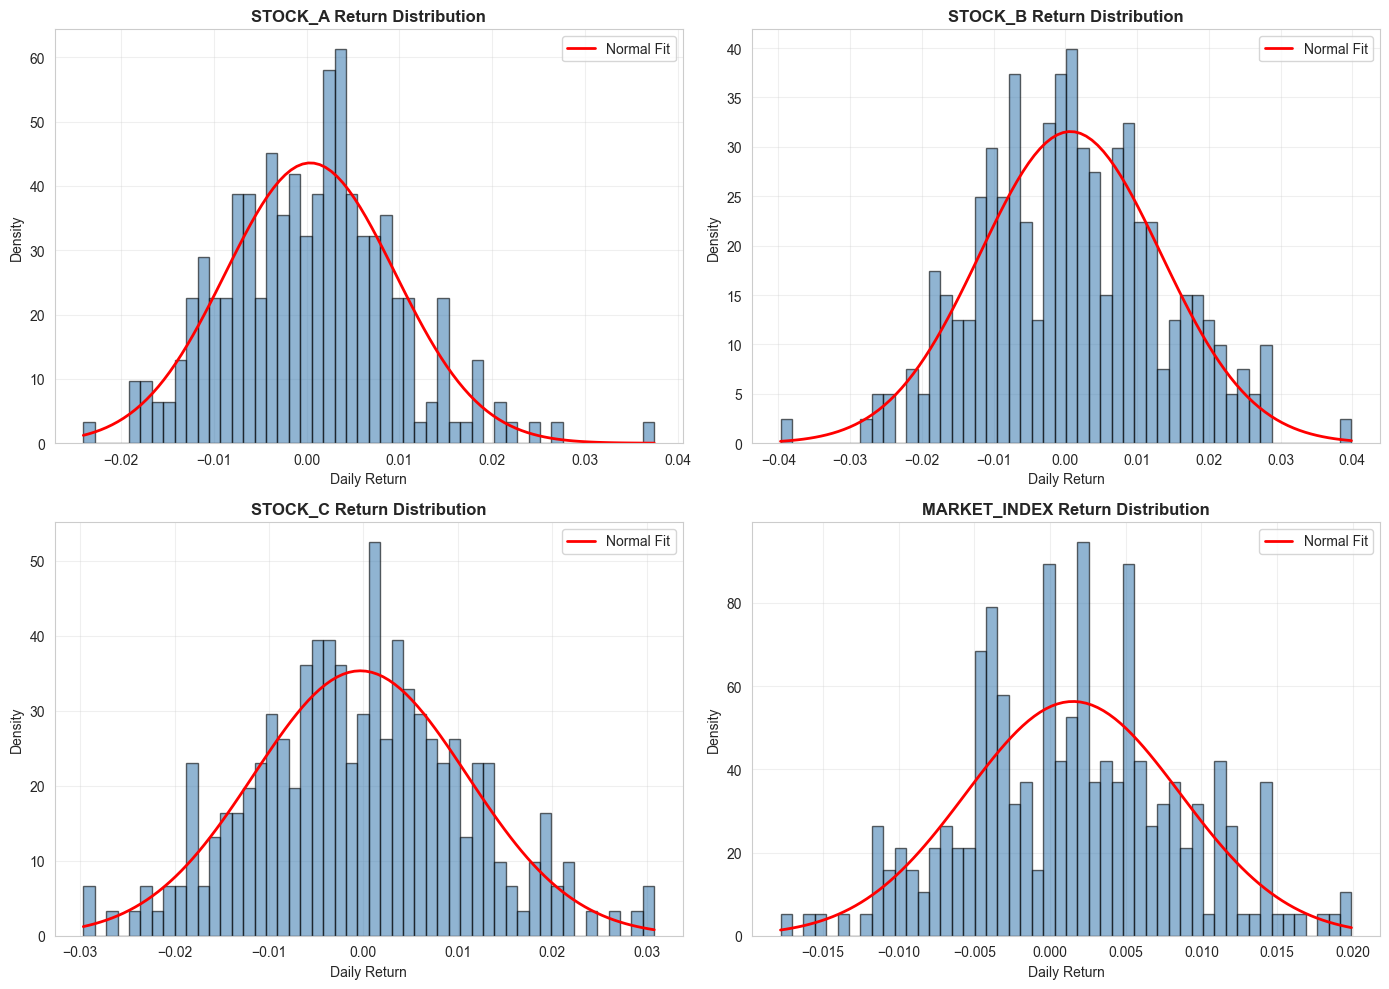

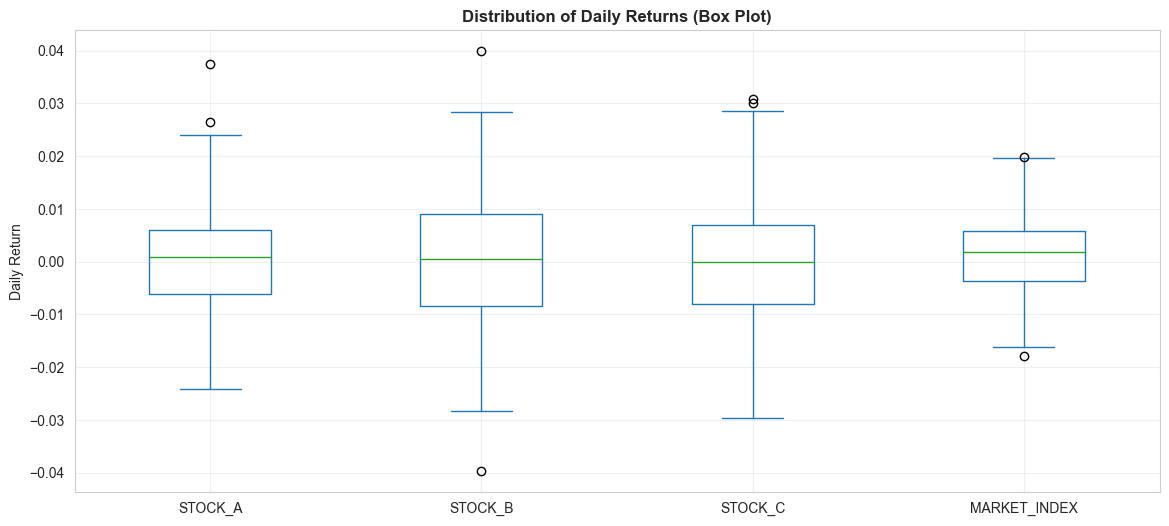

In [3]:
# Descriptive statistics
descriptive_stats = df_returns.describe()
descriptive_stats.loc['skewness'] = df_returns.skew()
descriptive_stats.loc['kurtosis'] = df_returns.kurtosis()
descriptive_stats.loc['annualized_vol'] = df_returns.std() * np.sqrt(252)

print("Descriptive Statistics (annualized volatility for comparison):")
print(descriptive_stats)

# Visualize return distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (ax, asset) in enumerate(zip(axes.flat, df_returns.columns)):
    returns = df_returns[asset]
    
    # Histogram with KDE
    ax.hist(returns, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')
    
    # Fit normal distribution
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Fit')
    
    ax.set_title(f'{asset} Return Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.figure(figsize=(14, 6))

# Box plots
df_returns.plot(kind='box', ax=plt.gca())
plt.title('Distribution of Daily Returns (Box Plot)', fontsize=12, fontweight='bold')
plt.ylabel('Daily Return')
plt.grid(alpha=0.3)
plt.show()

## 4. Return Distributions and Normality Tests

Test whether returns follow a normal distribution using Shapiro-Wilk and Jarque-Bera tests. Visualize using Q-Q plots to check normality assumption.

### Why Do We Need Normality Tests?

**The Core Problem:** Most classical finance models assume returns are normally distributed. If they aren't, every downstream model (Black-Scholes, parametric VaR, linear regression) has a structural flaw built in.

**Practical Examples:**
- **Black-Scholes Limitations**: The Black-Scholes options pricing formula assumes log-normal returns. Normality tests on the underlying stock reveal how badly this assumption breaks — and therefore how much model error the options desk is running.
- **Parametric VaR Validation**: A risk manager calculates parametric VaR assuming normality. If the Shapiro-Wilk test rejects normality (p < 0.05), this VaR is systematically wrong — typically underestimating loss by 20–40% at 99% confidence.
- **2008 Financial Crisis**: Many CDO pricing models assumed normally distributed asset returns. In reality, equity and credit returns had strong negative skew and excess kurtosis. The normality assumption caused catastrophic underpricing of tail risk.
- **Factor Model Validity**: Regression models (CAPM, Fama-French) have t-test significance results that assume normal residuals. Testing normality on regression residuals validates or invalidates those t-statistics.

**The Q-Q Plot Diagnostic:**
- Points falling on the diagonal line → normal distribution holds
- Points curling away at the tails → fat tails (kurtosis > 3)
- Points asymmetrically deviating → skewed distribution

**Decision Tree:**
```
Reject Normality?
  → YES → Use historical simulation VaR, not parametric
           Use Student's t-distribution for heavy tails  
           Consider Cornish-Fisher adjustment for skewness
  → NO  → Parametric models are appropriate approximations
```

NORMALITY TESTS

        Asset  SW Statistic  SW p-value  JB Statistic  JB p-value Normal (α=0.05)
     STOCK_A      0.989986    0.079971      9.072389    0.010714              No
     STOCK_B      0.996264    0.813118      0.453294    0.797202             Yes
     STOCK_C      0.997274    0.947769      0.457353    0.795586             Yes
MARKET_INDEX      0.996092    0.783690      0.558437    0.756375             Yes

Note: p-value < 0.05 suggests rejection of normality assumption


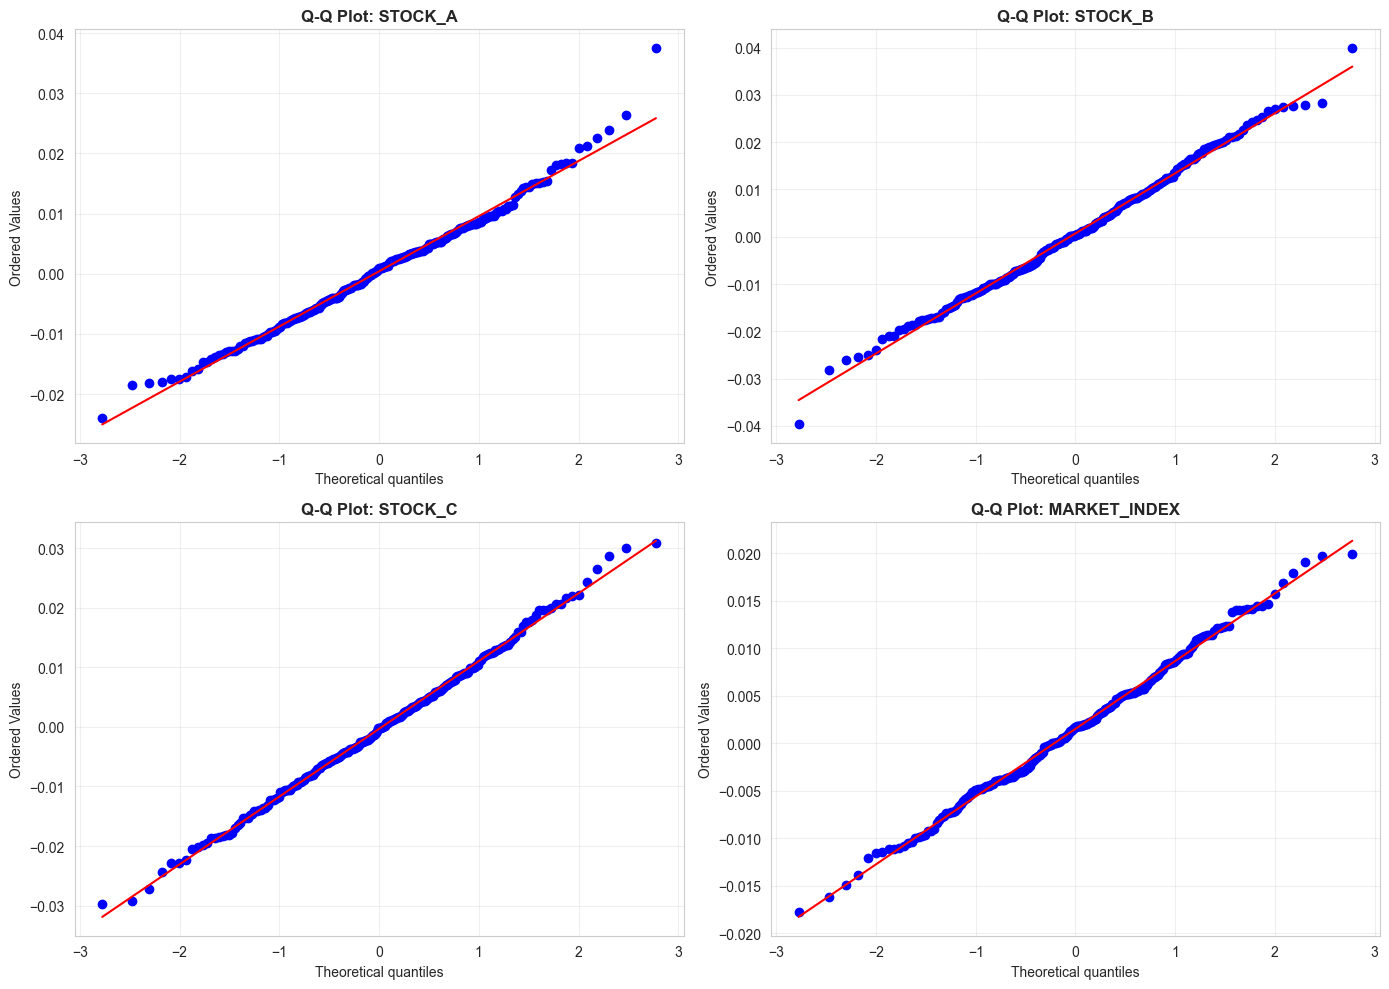

In [4]:
# Normality tests
print("=" * 70)
print("NORMALITY TESTS")
print("=" * 70)

normality_results = []
for asset in df_returns.columns:
    returns = df_returns[asset]
    
    # Shapiro-Wilk Test
    sw_stat, sw_pvalue = shapiro(returns)
    
    # Jarque-Bera Test
    jb_stat, jb_pvalue = jarque_bera(returns)
    
    normality_results.append({
        'Asset': asset,
        'SW Statistic': sw_stat,
        'SW p-value': sw_pvalue,
        'JB Statistic': jb_stat,
        'JB p-value': jb_pvalue,
        'Normal (α=0.05)': 'No' if min(sw_pvalue, jb_pvalue) < 0.05 else 'Yes'
    })
    
normality_df = pd.DataFrame(normality_results)
print("\n", normality_df.to_string(index=False))
print("\nNote: p-value < 0.05 suggests rejection of normality assumption")

# Q-Q plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, asset in zip(axes.flat, df_returns.columns):
    returns = df_returns[asset]
    stats.probplot(returns, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: {asset}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Rolling Statistics and Volatility

Compute rolling mean, rolling standard deviation, and annualized volatility over time. This captures how risk and returns evolve dynamically in financial markets.

### Why Do We Need Rolling Statistics and Volatility?

**The Core Problem:** A single annualized volatility number hides everything interesting. Volatility is not constant — it spikes in crashes, collapses in calm markets, and clusters in time.

**Practical Examples:**
- **Dynamic Hedging (Options Desks)**: Delta hedging requires knowing current volatility, not long-run average. Traders use 20-day rolling volatility as a proxy for near-term realized volatility to price and hedge gamma risk accurately.
- **Risk Parity Portfolios**: Risk parity strategies (e.g., Bridgewater's All Weather) rebalance periodically based on rolling 60-day volatility. When a stock's vol doubles, its position is halved to maintain equal risk contribution across the portfolio.
- **Volatility Regime Detection**: Rolling 21-day vol crossing above 30% annualized is a common trigger to reduce equity exposure in systematic trend-following funds (Winton, AHL, Man AHL).
- **Algorithmic Trading Position Sizing**: The Kelly Criterion and other position sizing formulas require current volatility as inputs. Stale annual σ systematically over-sizes positions after vol spikes.
- **The VIX Analogy**: The CBOE VIX index is essentially 30-day implied volatility. Rolling realized volatility over 21 trading days is the ex-post counterpart — comparing implied vs realized is the basis of volatility arbitrage trading.

**Risk-Return Visualization:**
The risk-return scatter plot tells a portfolio manager which assets offer the best return-per-unit-of-risk — the foundation for portfolio optimization and efficient frontier construction in mean-variance analysis.

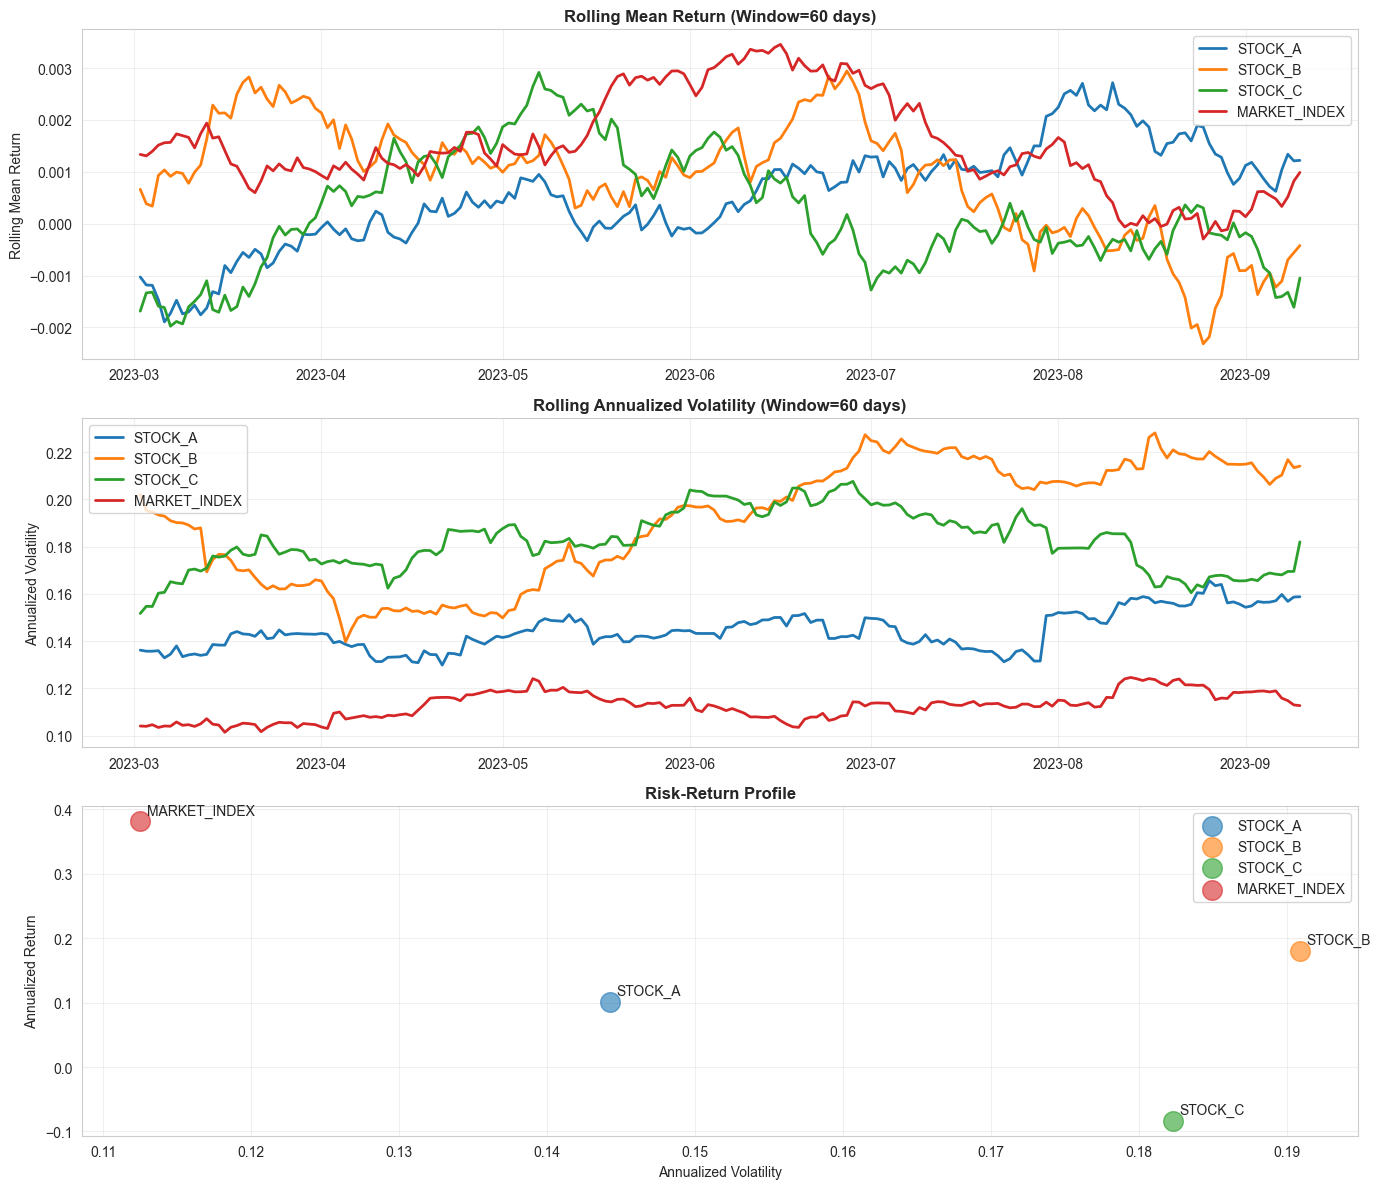

In [5]:
# Rolling statistics (60-day window)
window = 60

rolling_mean = df_returns.rolling(window=window).mean()
rolling_std = df_returns.rolling(window=window).std()
rolling_volatility = rolling_std * np.sqrt(252)  # Annualized

# Plot rolling statistics
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Rolling Mean
ax = axes[0]
for asset in df_returns.columns:
    ax.plot(rolling_mean.index, rolling_mean[asset], label=asset, linewidth=2)
ax.set_title(f'Rolling Mean Return (Window={window} days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Rolling Mean Return')
ax.legend()
ax.grid(alpha=0.3)

# Rolling Volatility
ax = axes[1]
for asset in df_returns.columns:
    ax.plot(rolling_volatility.index, rolling_volatility[asset], label=asset, linewidth=2)
ax.set_title(f'Rolling Annualized Volatility (Window={window} days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Annualized Volatility')
ax.legend()
ax.grid(alpha=0.3)

# Annualized Return vs Risk
ax = axes[2]
annual_returns = df_returns.mean() * 252
annual_vols = rolling_volatility.mean()
for asset in df_returns.columns:
    ax.scatter(annual_vols[asset], annual_returns[asset], s=200, alpha=0.6, label=asset)
    ax.annotate(asset, (annual_vols[asset], annual_returns[asset]), xytext=(5, 5), 
                textcoords='offset points', fontsize=10)
ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Return')
ax.set_title('Risk-Return Profile', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 5. Variance vs Covariance — The Building Blocks of Portfolio Risk

These two measures are the **foundation of every risk model in finance**. Understanding them is the key to understanding why diversification works, what the correlation matrix actually means, and how portfolio optimisation is even possible.

> **Variance** answers: *"How risky is this one asset by itself?"*
> **Covariance** answers: *"When I hold two assets together, do their risks add up or cancel out?"*

### Why Do We Need Variance AND Covariance?

**The Core Problem:** Variance tells you how risky *one* asset is in isolation. But portfolios hold *many* assets, and what matters is how those assets interact with each other — that's what covariance captures.

---

#### 🎯 Variance — "How Wildly Does ONE Asset Move?"

Variance measures how spread out a single asset's daily returns are around its average.

> **Everyday analogy:** Imagine two part-time jobs:
> - **Job A** always pays exactly \$100/day — *low variance*, very predictable
> - **Job B** pays anywhere from \$0 to \$500/day — *high variance*, very unpredictable

**The formula:**
$$\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(r_i - \bar{r})^2$$

We *square* each difference so that large swings in either direction both count as risky. Taking the square root gives **standard deviation** (σ) — more intuitive because it's in the same units as returns.

| Annual σ | Interpretation |
|----------|---------------|
| ≈ 5–8%   | Bond / defensive stock — moves slowly |
| ≈ 12–20% | Typical large-cap equity |
| ≈ 30–50% | High-growth tech stock |
| > 60%    | Speculative / crypto |

---

#### 🎯 Covariance — "Do TWO Assets Move in the Same Direction?"

Covariance answers: when Asset A has a bad day, does Asset B *also* have a bad day?

> **Everyday analogy:** Two businesses you could invest in:
> - **Beach café + Sunscreen shop** → both do well on sunny days, both fail on rainy days → **positive covariance** (risky — they crash together)
> - **Beach café + Umbrella shop** → one thrives when the other suffers → **negative covariance** (safe — they hedge each other naturally)

**The formula:**
$$\text{Cov}(A, B) = \frac{1}{N}\sum_{i=1}^{N}\bigl(r_i^A - \bar{r}^A\bigr)\bigl(r_i^B - \bar{r}^B\bigr)$$

Positive products (both above average *or* both below average on the same day) make covariance positive. Mixed products cancel out.

| Covariance sign | Meaning | Portfolio effect |
|-----------------|---------|-----------------|
| **Positive (+)** | Move in the same direction | Risk **adds up** — no diversification benefit |
| **≈ Zero (0)** | No relationship | Partial diversification |
| **Negative (−)** | Move in opposite directions | Risk **cancels** — maximum diversification benefit! |

---

#### 🎯 The Portfolio Variance Formula — Why Covariance Changes Everything

If you hold 50% Asset A and 50% Asset B:

$$\sigma^2_\text{portfolio} = \underbrace{w_A^2\,\sigma_A^2}_\text{risk from A} + \underbrace{w_B^2\,\sigma_B^2}_\text{risk from B} + \underbrace{2\,w_A\,w_B\,\text{Cov}(A,B)}_\text{interaction term ← this is KEY}$$

- If **Cov > 0**: the last term is *positive* → portfolio variance is **higher** than the naive sum
- If **Cov = 0**: the last term is *zero* → portfolio variance equals the naive sum
- If **Cov < 0**: the last term is *negative* → portfolio variance is **lower** than the naive sum 🎉

This is the mathematical proof of why **diversification works**: mixing assets that don't move together reduces total risk even without changing individual asset risks.

---

#### 💡 Covariance vs Correlation: One More Step

Covariance has units (% × %) so it's hard to compare across different asset pairs. **Correlation** solves this by dividing by both standard deviations, giving a unitless number in [−1, +1]:

$$\rho(A, B) = \frac{\text{Cov}(A,B)}{\sigma_A \cdot \sigma_B}$$

| Concept | What it measures | Range | Best used for |
|---------|-----------------|-------|--------------|
| Variance | Spread of **one** asset | ≥ 0 (unbounded) | Measuring individual risk |
| Covariance | Joint movement of **two** assets | Unbounded | Portfolio risk formula |
| Correlation | *Normalised* joint movement | [−1, +1] | Comparing any pair of assets |

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# Section 5: Variance vs Covariance — live calculations and visualisations
# ─────────────────────────────────────────────────────────────────────────────

asset_a = df_returns['STOCK_A']
asset_b = df_returns['STOCK_B']

# Core numbers we'll reference throughout
var_A   = asset_a.var()
var_B   = asset_b.var()
cov_AB  = asset_a.cov(asset_b)
std_A   = asset_a.std()
std_B   = asset_b.std()
w = 0.5   # 50/50 portfolio split

# Portfolio variance under three scenarios (annualised)
var_A_only          = var_A  * 252
var_naive_portfolio = (w**2 * var_A + w**2 * var_B) * 252                              # ignoring covariance
var_real_portfolio  = (w**2 * var_A + w**2 * var_B + 2*w*w * cov_AB) * 252             # actual covariance
var_hedge_portfolio = (w**2 * var_A + w**2 * var_B - 2*w*w * abs(cov_AB)) * 252        # hypothetical negative cov

# ── Print table ───────────────────────────────────────────────────────────────
print("=" * 72)
print("VARIANCE — individual risk of each asset (annualised)")
print("=" * 72)
print(f"\n{'Asset':<15} {'Daily Var σ²':>14} {'Annual Var σ²':>14} "
      f"{'Daily Std σ':>12} {'Annual Std σ':>12}")
print("-" * 70)
for asset in df_returns.columns:
    dv  = df_returns[asset].var()
    av  = dv * 252
    ds  = df_returns[asset].std()
    as_ = ds * np.sqrt(252)
    print(f"{asset:<15} {dv:>14.6f} {av:>14.6f} {ds:>11.2%} {as_:>11.2%}")

print("\n" + "=" * 72)
print("COVARIANCE — joint movement between pairs of assets (daily)")
print("=" * 72)
assets_list = df_returns.columns.tolist()
print(f"\n{'Pair':<30} {'Covariance':>14} {'Interpretation':>25}")
print("-" * 72)
for i in range(len(assets_list)):
    for j in range(i + 1, len(assets_list)):
        cov = df_returns[assets_list[i]].cov(df_returns[assets_list[j]])
        interp = "▲ Move together (risk adds up)" if cov > 0 else "▼ Move opposite (risk cancels)"
        print(f"{assets_list[i] + ' vs ' + assets_list[j]:<30} {cov:>14.8f}  {interp}")

print("\n" + "=" * 72)
print("PORTFOLIO VARIANCE — why covariance changes your total risk")
print("=" * 72)
print(f"\n50/50 portfolio: STOCK_A + STOCK_B")
print(f"  Var(A alone)              = {var_A_only:.6f}  → σ = {np.sqrt(var_A_only):.2%}")
print(f"  Naive (ignoring cov)      = {var_naive_portfolio:.6f}  → σ = {np.sqrt(var_naive_portfolio):.2%}  ← wrong!")
print(f"  Correct (actual cov)      = {var_real_portfolio:.6f}  → σ = {np.sqrt(var_real_portfolio):.2%}  ← real answer")
print(f"  Hypothetical (neg. cov)   = {var_hedge_portfolio:.6f}  → σ = {np.sqrt(var_hedge_portfolio):.2%}  ← best case")
print(f"\n  → Diversification saving (actual vs naive): "
      f"{(np.sqrt(var_naive_portfolio) - np.sqrt(var_real_portfolio)):.2%}")

# ── 4-panel figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Variance vs Covariance — Four Ways to See the Difference',
             fontsize=14, fontweight='bold')

palette = {'STOCK_A': '#2196F3', 'STOCK_B': '#FF5722',
           'STOCK_C': '#4CAF50', 'MARKET_INDEX': '#9C27B0'}

# ── Panel 1: Return time series — do they move together? ──────────────────────
ax = axes[0, 0]
ax.plot(df_returns.index, asset_a, alpha=0.65, color=palette['STOCK_A'],
        lw=1, label='STOCK_A')
ax.plot(df_returns.index, asset_b, alpha=0.65, color=palette['STOCK_B'],
        lw=1, label='STOCK_B')
ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
ax.set_title('① Daily Returns Over Time\n"Do they move together?"', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Return')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
# Annotate covariance sign
sign_text = "Positive covariance:\nbig moves tend to be in the same direction" if cov_AB > 0 \
            else "Negative covariance:\nmoves tend to be in opposite directions"
ax.text(0.02, 0.03, sign_text, transform=ax.transAxes, fontsize=8.5,
        color='#555555', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.85))

# ── Panel 2: Scatter plot — variance = spread, covariance = tilt ──────────────
ax = axes[0, 1]
ax.scatter(asset_a, asset_b, alpha=0.35, s=12, color='#4CAF50', label='Daily obs')
m, b_int = np.polyfit(asset_a, asset_b, 1)
x_line = np.linspace(asset_a.min(), asset_a.max(), 100)
ax.plot(x_line, m * x_line + b_int, 'r-', lw=2,
        label=f'Trend (slope ∝ Cov = {cov_AB:.6f})')
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.axvline(0, color='gray', lw=0.5, linestyle='--')

# Annotate spread on x-axis = variance of A
y_mid = (asset_b.min() + asset_b.max()) / 2
ax.annotate('', xy=(asset_a.mean() + std_A, y_mid * 1.6),
            xytext=(asset_a.mean() - std_A, y_mid * 1.6),
            arrowprops=dict(arrowstyle='<->', color='#2196F3', lw=2))
ax.text(asset_a.mean(), y_mid * 1.6 + 0.002,
        f'±σ_A = ±{std_A:.3f}\n(width = variance of A)',
        ha='center', va='bottom', color='#2196F3', fontsize=8, fontweight='bold')

ax.set_xlabel(f'STOCK_A daily return  (σ² = {var_A:.5f})', fontsize=9)
ax.set_ylabel(f'STOCK_B daily return  (σ² = {var_B:.5f})', fontsize=9)
ax.set_title('② Scatter Plot\n"Spread on each axis = Variance, Tilt = Covariance"',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Panel 3: Annualised variance bar chart ────────────────────────────────────
ax = axes[1, 0]
ann_vars = df_returns.var() * 252
ann_stds = df_returns.std() * np.sqrt(252)
bar_colors = [palette[a] for a in ann_vars.index]
bars = ax.bar(ann_vars.index, ann_vars.values, color=bar_colors, alpha=0.82,
              edgecolor='black', linewidth=0.8)
for bar, val, std_val in zip(bars, ann_vars.values, ann_stds.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + ann_vars.max() * 0.01,
            f'σ² = {val:.4f}\nσ = {std_val:.1%}',
            ha='center', va='bottom', fontsize=8.5)
ax.set_title('③ Variance of Each Asset (Annualised)\n"Higher = more unpredictable daily moves"',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Annualised Variance (σ²)')
ax.set_xlabel('Asset')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# ── Panel 4: Portfolio variance — the covariance effect ──────────────────────
ax = axes[1, 1]
labels  = ['Only\nSTOCK_A', '50/50\n(ignore cov)', '50/50\n(real cov)', '50/50\n(neg. cov)']
vals    = [var_A_only, var_naive_portfolio, var_real_portfolio, var_hedge_portfolio]
colors4 = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
bars2   = ax.bar(labels, vals, color=colors4, alpha=0.85, edgecolor='black', linewidth=0.8)
for bar, v in zip(bars2, vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.01,
            f'σ² = {v:.5f}\nσ = {np.sqrt(v):.1%}',
            ha='center', va='bottom', fontsize=8.5)
ax.set_title('④ Portfolio Variance — Covariance Changes Everything\n"Same 2 assets, same 50/50 weight"',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Annualised Portfolio Variance')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Add a legend explaining the four bars
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#2196F3', label='Baseline: one asset alone'),
    Patch(color='#FF9800', label='Ignoring covariance (wrong)'),
    Patch(color='#4CAF50', label='Correct: real covariance included'),
    Patch(color='#E91E63', label='Best case: assets move opposite'),
]
ax.legend(handles=legend_handles, fontsize=7.5, loc='upper right')

plt.tight_layout()
plt.show()


## 6. Correlation and Covariance Analysis

Compute pairwise correlation and covariance matrices. High correlation indicates assets move together, affecting portfolio diversification benefits.

### Why Do We Need Correlation and Covariance Analysis?

**The Core Problem:** Holding two assets that move together provides no diversification benefit — you're just taking the same bet twice with more capital.

**Practical Examples:**
- **Portfolio Diversification (Markowitz Theory)**: The efficient frontier is only possible when correlations are below 1.0. Adding an asset with ρ = 0.2 to a portfolio reduces overall variance even if the added asset has *higher* standalone volatility.
- **The 2008 Correlation Crisis**: Before the crisis, mortgage-backed securities (MBS) from different geographic regions had historically low correlations (~0.3). During the crisis all correlations jumped to near 1.0 simultaneously — a phenomenon called "correlation breakdown." Portfolios built on low-correlation assumptions lost catastrophically.
- **Macro Factor Investing**: Quantitative equity strategies check correlations between factor exposures (value, momentum, quality). If value and momentum are negatively correlated, combining them in one portfolio creates a natural hedge and reduces drawdowns.
- **Fixed Income + Equity Correlation**: Classic 60/40 portfolios work because bonds and equities are typically negatively correlated. When inflation spikes (2022), this negative correlation breaks down — both fall simultaneously, eliminating the hedge.
- **Covariance for Position Sizing**: The covariance matrix is the direct input to portfolio optimization (min variance: $w^T \Sigma w$). Using daily covariance × 252 gives the annualized portfolio variance needed for Sharpe ratio calculation.

**Correlation vs. Covariance:**
| Measure | Range | Interpretable? | Use Case |
|---------|-------|---------------|----------|
| Correlation | [−1, +1] | Yes (scale-free) | Comparison across assets |
| Covariance | Unbounded | No (scale-dependent) | Portfolio variance calculation |

CORRELATION MATRIX
               STOCK_A   STOCK_B   STOCK_C  MARKET_INDEX
STOCK_A       1.000000  0.022046  0.093245      0.010728
STOCK_B       0.022046  1.000000 -0.100986      0.013682
STOCK_C       0.093245 -0.100986  1.000000      0.022157
MARKET_INDEX  0.010728  0.013682  0.022157      1.000000

COVARIANCE MATRIX (Daily)
                   STOCK_A   STOCK_B   STOCK_C  MARKET_INDEX
STOCK_A       8.382937e-05  0.000003  0.000010  6.960172e-07
STOCK_B       2.552523e-06  0.000160 -0.000014  1.225966e-06
STOCK_C       9.646243e-06 -0.000014  0.000128  1.773995e-06
MARKET_INDEX  6.960172e-07  0.000001  0.000002  5.021283e-05

COVARIANCE MATRIX (Annualized)
               STOCK_A   STOCK_B   STOCK_C  MARKET_INDEX
STOCK_A       0.021125  0.000643  0.002431      0.000175
STOCK_B       0.000643  0.040296 -0.003636      0.000309
STOCK_C       0.002431 -0.003636  0.032172      0.000447
MARKET_INDEX  0.000175  0.000309  0.000447      0.012654


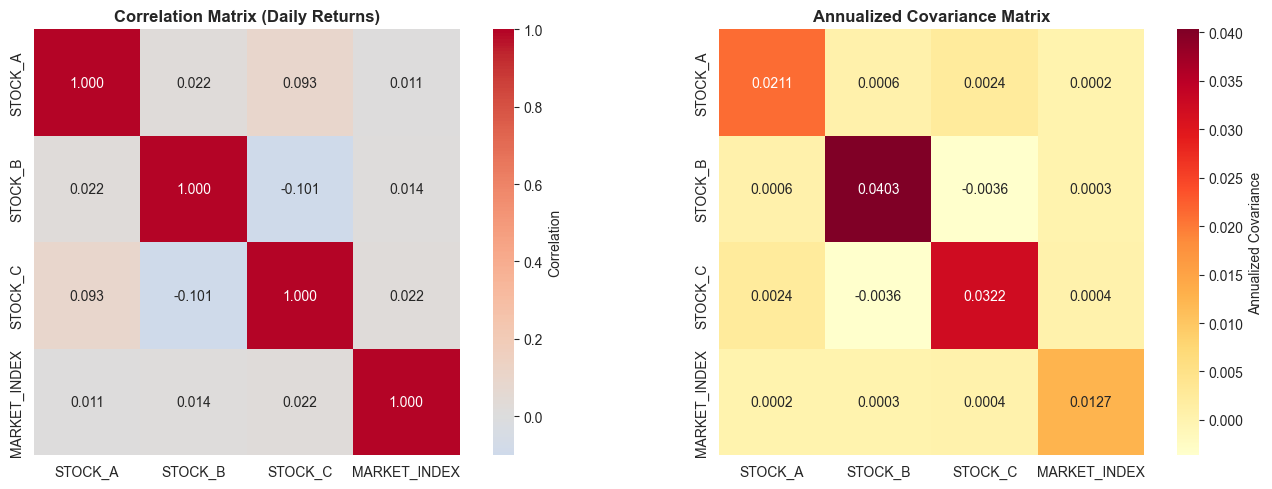

In [6]:
# Correlation matrix
corr_matrix = df_returns.corr()
cov_matrix = df_returns.cov()

print("=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)
print(corr_matrix)

print("\n" + "=" * 70)
print("COVARIANCE MATRIX (Daily)")
print("=" * 70)
print(cov_matrix)

# Annualized covariance
annual_cov_matrix = cov_matrix * 252

print("\n" + "=" * 70)
print("COVARIANCE MATRIX (Annualized)")
print("=" * 70)
print(annual_cov_matrix)

# Visualize correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix (Daily Returns)', fontsize=12, fontweight='bold')

# Covariance heatmap (annualized)
sns.heatmap(annual_cov_matrix, annot=True, fmt='.4f', cmap='YlOrRd', 
            square=True, ax=axes[1], cbar_kws={'label': 'Annualized Covariance'})
axes[1].set_title('Annualized Covariance Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Value at Risk (VaR) and Expected Shortfall (ES)

Calculate Value at Risk (VaR) using historical and parametric methods, and Expected Shortfall (CVaR) at 95% and 99% confidence levels. These measure tail risk in portfolios.

### Why Do We Need Value at Risk (VaR) and Expected Shortfall?

**The Core Problem:** "Average" losses are mostly irrelevant — it's the catastrophic tail losses that destroy institutions. VaR asks: "How bad could things get on my worst days?"

**Practical Examples:**
- **Basel Regulatory Capital**: Under Basel III, every bank with a trading book must calculate VaR daily and hold capital equal to 3× the 10-day 99% VaR. A bank computing VaR incorrectly faces massive undercapitalization and regulatory penalties.
- **Hedge Fund Drawdown Management**: When a long/short equity fund hits −2× its daily VaR for three consecutive days, risk managers are required to reduce gross exposure. VaR is the mechanical trigger for de-risking.
- **Why VaR Alone Is Insufficient**: VaR at 95% tells you the loss threshold you'll exceed 5% of days. But it says nothing about how bad those 5% of days are. Expected Shortfall (CVaR) fills this gap by averaging those worst-case losses.
  - Example: Two portfolios both have 95% VaR of −$1M. But Portfolio A's average loss when VaR is breached is −$1.2M, while Portfolio B's is −$3.5M. ES distinguishes between them; VaR does not.
- **Lehman Brothers 2008**: Lehman's risk models showed acceptable daily VaR. However, their ES (tail risk) was catastrophically underestimated due to concentrated illiquid positions that had model-assigned low volatility. The lesson: always look beyond VaR.
- **FRTB (Fundamental Review of the Trading Book)**: Post-2010 regulation replaced 99% VaR with 97.5% ES as the primary risk measure — explicitly because ES captures tail behavior that VaR misses.

**Risk Interpretation at a Glance:**
$$\text{VaR}_{95\%} = -2.5\% \text{ daily} \implies \text{On 1 in 20 trading days, you lose > 2.5\% of portfolio value}$$

$$\text{ES}_{95\%} = -3.8\% \text{ daily} \implies \text{When VaR is breached, expected loss is 3.8\%}$$

VALUE AT RISK (VaR) AND EXPECTED SHORTFALL (ES)
       Asset Confidence  VaR Historical  VaR Parametric  Expected Shortfall
     STOCK_A        95%       -0.013635       -0.014657           -0.016946
     STOCK_A        99%       -0.018084       -0.020897           -0.020281
     STOCK_B        95%       -0.018620       -0.020084           -0.023759
     STOCK_B        99%       -0.025741       -0.028702           -0.031360
     STOCK_C        95%       -0.018591       -0.018916           -0.022745
     STOCK_C        99%       -0.025706       -0.026616           -0.028659
MARKET_INDEX        95%       -0.010192       -0.010144           -0.012527
MARKET_INDEX        99%       -0.014386       -0.014973           -0.016301


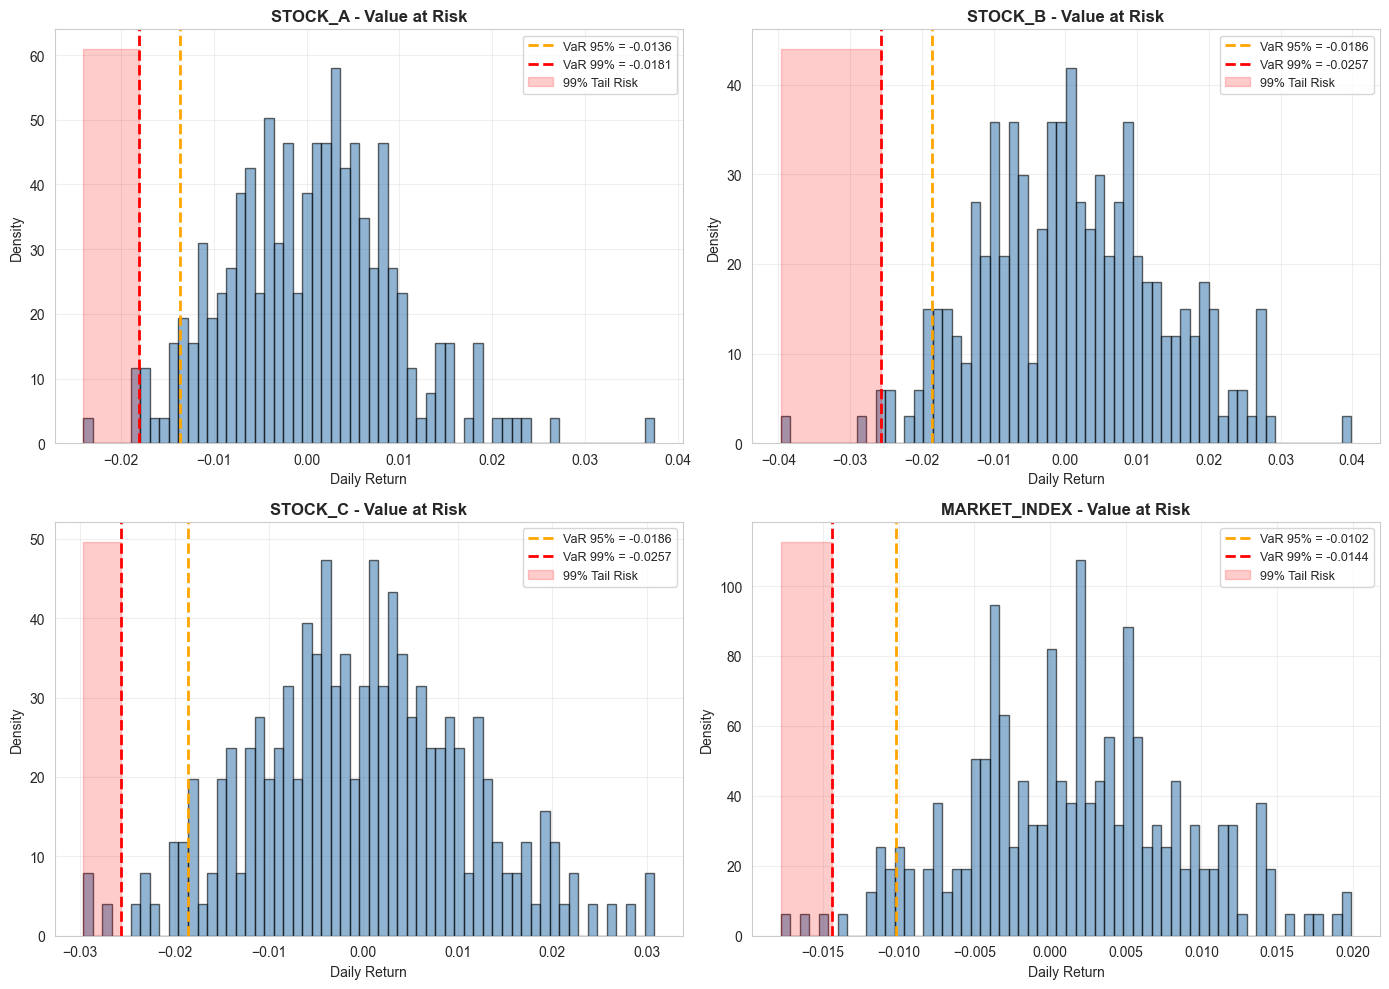

In [7]:
# VaR and Expected Shortfall calculation
confidence_levels = [0.95, 0.99]

var_es_results = []
for asset in df_returns.columns:
    returns = df_returns[asset]
    
    for conf_level in confidence_levels:
        alpha = 1 - conf_level
        
        # Historical VaR
        var_historical = np.percentile(returns, alpha * 100)
        
        # Parametric VaR (assuming normal distribution)
        mean_ret = returns.mean()
        std_ret = returns.std()
        z_score = norm.ppf(alpha)
        var_parametric = mean_ret + z_score * std_ret
        
        # Expected Shortfall (CVaR)
        es = returns[returns <= var_historical].mean()
        
        var_es_results.append({
            'Asset': asset,
            'Confidence': f'{conf_level*100:.0f}%',
            'VaR Historical': var_historical,
            'VaR Parametric': var_parametric,
            'Expected Shortfall': es
        })

var_df = pd.DataFrame(var_es_results)
print("=" * 100)
print("VALUE AT RISK (VaR) AND EXPECTED SHORTFALL (ES)")
print("=" * 100)
print(var_df.to_string(index=False))

# Visualize VaR
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (ax, asset) in enumerate(zip(axes.flat, df_returns.columns)):
    returns = df_returns[asset]
    
    # Plot histogram
    ax.hist(returns, bins=60, alpha=0.6, color='steelblue', edgecolor='black', density=True)
    
    # Mark VaR levels
    var_95 = np.percentile(returns, 5)  # 5% left tail
    var_99 = np.percentile(returns, 1)  # 1% left tail
    
    ax.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'VaR 95% = {var_95:.4f}')
    ax.axvline(var_99, color='red', linestyle='--', linewidth=2, label=f'VaR 99% = {var_99:.4f}')
    
    # Fill tail risk
    x_min = returns.min()
    ax.fill_between([x_min, var_99], 0, ax.get_ylim()[1], alpha=0.2, color='red', label='99% Tail Risk')
    
    ax.set_title(f'{asset} - Value at Risk', fontsize=12, fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Beta and Capital Asset Pricing Model (CAPM)

Estimate asset beta relative to a market index using OLS regression. Calculate expected return using CAPM: $E(R_i) = R_f + \beta_i (E(R_m) - R_f)$

### Why Do We Need Beta and CAPM?

**The Core Problem:** Not all risk is the same. Some risk can be eliminated by diversification — some cannot. Beta separates the two and prices only the unavoidable part.

**Practical Examples:**
- **Equity Fund Manager Attribution**: A fund returned +30% this year. Good, right? Only if CAPM expected return was +15%. If beta = 2.0 and the market rose 20%, CAPM expected +40% — so the fund actually *underperformed* on a risk-adjusted basis despite the impressive absolute return.
- **Smart Beta ETFs**: Fundamental indexing strategies (e.g., iShares MSCI Minimum Volatility) explicitly target beta < 1.0. Low-beta stocks historically provide better risk-adjusted returns — the "low-volatility anomaly" that contradicts CAPM predictions.
- **Currency Hedging Decisions**: A UK pension fund holding US equities calculates beta of USD/GBP exchange rate against portfolio returns. High beta → hedge FX risk. Low beta → the natural hedge is already working.
- **Benchmarked Portfolio Construction**: A long-only equity fund with a tracking error constraint must know each stock's beta to the benchmark to build a portfolio with target beta ≈ 1.05 (slight tilt toward the market).
- **Leveraged Buyout Valuation**: In LBO modeling, beta is used to calculate the weighted average cost of capital (WACC) as the discount rate for DCF valuation. A higher beta stock has higher cost of equity, lower present value.

**Interpreting Beta:**
| Beta Value | Behavior | Example |
|-----------|----------|---------|
| β < 0 | Moves opposite the market (inverse ETFs, gold) | −0.3 |
| β = 0 | No correlation with market (T-bills) | 0 |
| 0 < β < 1 | Less volatile than market (utilities, staples) | 0.6 |
| β = 1 | Moves with the market (S&P 500 index fund) | 1.0 |
| β > 1 | More volatile than market (tech, growth stocks) | 1.8 |

**CAPM Used in Practice:**
$$E(R_i) = R_f + \beta_i \underbrace{(E(R_m) - R_f)}_{\text{Market Risk Premium } \approx 5-7\%}$$

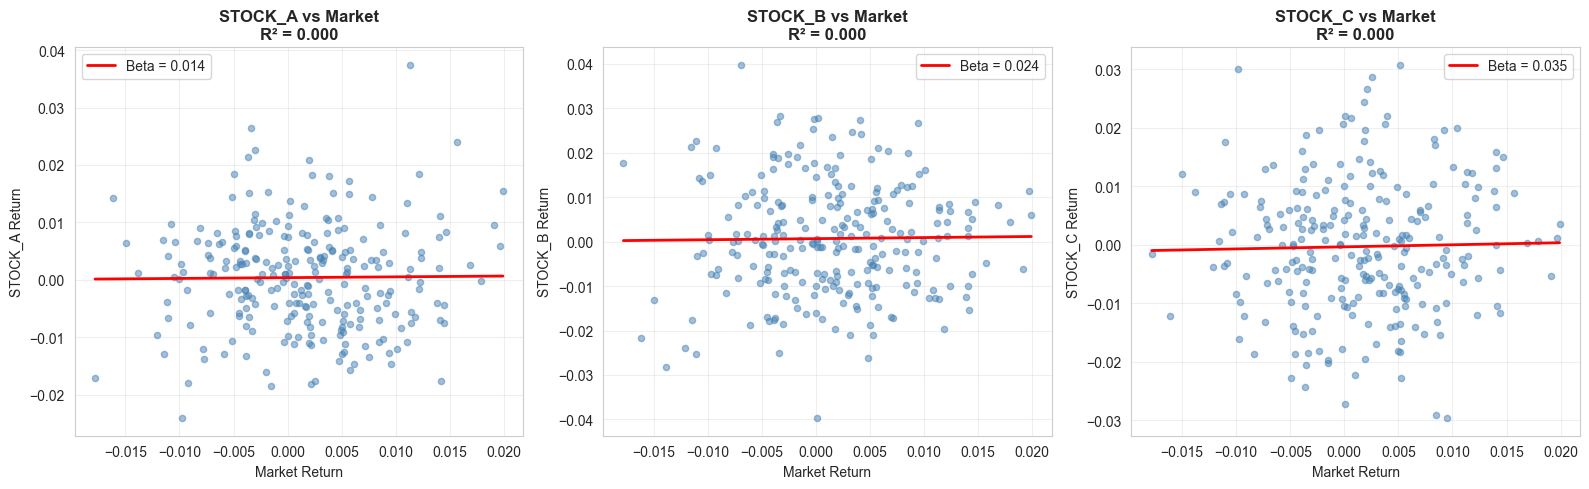

CAPM ANALYSIS
  Asset     Beta  Alpha (annualized)  R-squared  Expected Return (CAPM)
STOCK_A 0.013861            0.096267   0.000115                0.025003
STOCK_B 0.024415            0.171017   0.000187                0.028813
STOCK_C 0.035330           -0.096813   0.000491                0.032752

Risk-Free Rate (daily): 0.000079
Risk-Free Rate (annualized): 0.0200
Market Risk Premium (annualized): 0.3610


In [8]:
# CAPM and Beta calculation
market_returns = df_returns['MARKET_INDEX'].values.reshape(-1, 1)
risk_free_rate = 0.02 / 252  # Annual 2% converted to daily

capm_results = []
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

asset_names = ['STOCK_A', 'STOCK_B', 'STOCK_C']
for idx, (ax, asset) in enumerate(zip(axes.flat, asset_names)):
    asset_returns = df_returns[asset].values
    
    # OLS regression to estimate beta
    model = LinearRegression()
    model.fit(market_returns, asset_returns)
    beta = model.coef_[0]
    alpha = model.intercept_
    r_squared = model.score(market_returns, asset_returns)
    
    # CAPM expected return
    market_premium = (df_returns['MARKET_INDEX'].mean() - risk_free_rate) * 252
    expected_return = risk_free_rate * 252 + beta * market_premium
    
    capm_results.append({
        'Asset': asset,
        'Beta': beta,
        'Alpha (annualized)': alpha * 252,
        'R-squared': r_squared,
        'Expected Return (CAPM)': expected_return
    })
    
    # Plot regression
    ax.scatter(market_returns, asset_returns, alpha=0.5, s=20, color='steelblue')
    
    # Regression line
    x_line = np.linspace(market_returns.min(), market_returns.max(), 100)
    y_line = beta * x_line + alpha
    ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'Beta = {beta:.3f}')
    
    ax.set_xlabel('Market Return')
    ax.set_ylabel(f'{asset} Return')
    ax.set_title(f'{asset} vs Market\nR² = {r_squared:.3f}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

capm_df = pd.DataFrame(capm_results)
print("=" * 80)
print("CAPM ANALYSIS")
print("=" * 80)
print(capm_df.to_string(index=False))

print(f"\nRisk-Free Rate (daily): {risk_free_rate:.6f}")
print(f"Risk-Free Rate (annualized): {risk_free_rate * 252:.4f}")
print(f"Market Risk Premium (annualized): {market_premium:.4f}")

## 9. Time Series Analysis and Autocorrelation

Test for stationarity using the Augmented Dickey-Fuller test. Visualize ACF and PACF plots to detect serial correlation and volatility clustering.

### Why Do We Need Time Series Analysis and Autocorrelation?

**The Core Problem:** Standard statistical tests (regression, means comparison) assume data points are independent. Financial prices are not independent — today's price strongly depends on yesterday's. Ignoring this violates nearly every classical assumption.

**Practical Examples:**
- **Stationarity and Spurious Regression**: If you regress two non-stationary price series (e.g., Gold and SPX prices) against each other, you will almost always find a significant relationship — but it's completely spurious. The ADF test catches this before you build a model on a mathematical illusion.
- **ARIMA for Earnings Forecasting**: Corporate cash flow forecasting models use ARIMA to capture the autocorrelation structure in quarterly earnings. A model that ignores serial correlation leaves predictable information on the table (literally: the CFO's forecast would be more accurate with ARIMA).
- **Volatility Clustering (ARCH Effects)**: The ACF of squared returns detects if volatility clusters in time — periods of high vol follow high vol, low follows low. This is the foundation for GARCH models used by every major options market maker to forecast near-term realized vol.
- **Mean Reversion vs. Momentum**: ACF of raw returns identifies whether returns show positive autocorrelation (momentum → price continues in the same direction) or negative (mean reversion → price reverses). This directly determines whether to use momentum or mean-reversion trading strategies.
- **High-Frequency Trading Signal Validation**: Algorithmic trading firms test ACF of their order flow signals before deployment. If a signal has autocorrelation, it should either be modeled explicitly or removed — otherwise position sizing will be systematically wrong.

**What ACF/PACF Tell You:**
| Pattern | Interpretation | Implied Model |
|---------|---------------|---------------|
| ACF dies off, PACF cuts at lag p | Autoregressive structure | AR(p) |
| PACF dies off, ACF cuts at lag q | Moving average structure | MA(q) |
| Both slowly decay | Combination of AR and MA | ARMA(p,q) |
| ACF of **squared** returns significant | Volatility clustering (ARCH effects) | GARCH needed |

AUGMENTED DICKEY-FULLER TEST (Stationarity)
       Asset  ADF Statistic      p-value  Critical Value (5%) Stationary
     STOCK_A     -16.647685 1.614155e-29            -2.873125        Yes
     STOCK_B     -15.547196 2.122460e-28            -2.873125        Yes
     STOCK_C     -16.402845 2.628107e-29            -2.873125        Yes
MARKET_INDEX     -15.370229 3.516523e-28            -2.873125        Yes

Note: p-value < 0.05 indicates stationarity (rejection of unit root)


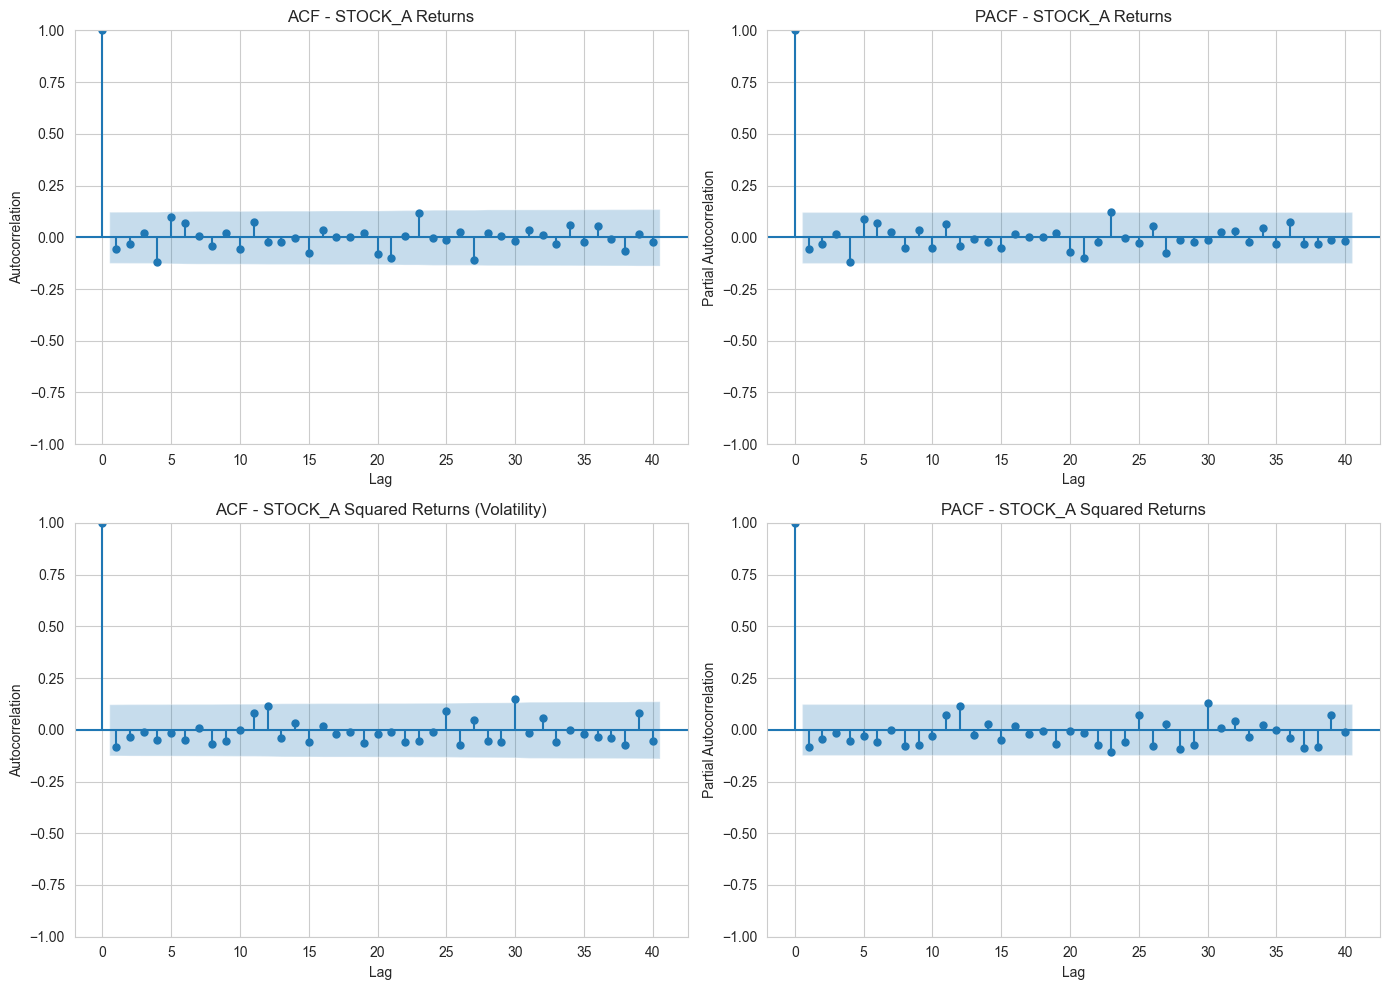


✓ Strong ACF in squared returns indicates volatility clustering
✓ This suggests ARCH/GARCH models may be useful for volatility forecasting


In [9]:
# Augmented Dickey-Fuller Test for Stationarity
adf_results = []
for asset in df_returns.columns:
    returns = df_returns[asset]
    adf_stat, p_value, n_lags, n_obs, crit_values, ic_best = adfuller(returns)
    
    adf_results.append({
        'Asset': asset,
        'ADF Statistic': adf_stat,
        'p-value': p_value,
        'Critical Value (5%)': crit_values['5%'],
        'Stationary': 'Yes' if p_value < 0.05 else 'No'
    })

adf_df = pd.DataFrame(adf_results)
print("=" * 80)
print("AUGMENTED DICKEY-FULLER TEST (Stationarity)")
print("=" * 80)
print(adf_df.to_string(index=False))
print("\nNote: p-value < 0.05 indicates stationarity (rejection of unit root)")

# ACF and PACF plots for one asset (STOCK_A)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ACF of returns
plot_acf(df_returns['STOCK_A'], lags=40, ax=axes[0, 0], title='ACF - STOCK_A Returns')
axes[0, 0].set_xlabel('Lag')
axes[0, 0].set_ylabel('Autocorrelation')

# PACF of returns
plot_pacf(df_returns['STOCK_A'], lags=40, ax=axes[0, 1], title='PACF - STOCK_A Returns')
axes[0, 1].set_xlabel('Lag')
axes[0, 1].set_ylabel('Partial Autocorrelation')

# ACF of squared returns (volatility clustering)
squared_returns = df_returns['STOCK_A'] ** 2
plot_acf(squared_returns, lags=40, ax=axes[1, 0], title='ACF - STOCK_A Squared Returns (Volatility)')
axes[1, 0].set_xlabel('Lag')
axes[1, 0].set_ylabel('Autocorrelation')

# PACF of squared returns
plot_pacf(squared_returns, lags=40, ax=axes[1, 1], title='PACF - STOCK_A Squared Returns')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

print("\n✓ Strong ACF in squared returns indicates volatility clustering")
print("✓ This suggests ARCH/GARCH models may be useful for volatility forecasting")

## 10. Monte Carlo Simulation for Portfolio Returns

Run Monte Carlo simulations using Geometric Brownian Motion (GBM): $S_t = S_0 \exp\left((\mu - \frac{\sigma^2}{2})t + \sigma W_t\right)$

Simulate multiple future price paths and analyze the distribution of portfolio returns.

### Why Do We Need Monte Carlo Simulation?

**The Core Problem:** Markets are stochastic — the future is not a single path but a distribution of possible outcomes. Analytical formulas exist only for simple cases. Monte Carlo provides the probability distribution of outcomes for any portfolio, structure, or scenario.

**Practical Examples:**
- **Exotic Options Pricing**: A barrier option pays out only if the underlying never crosses a certain price during the option's life. There is no closed-form solution for most path-dependent options. Banks price them entirely through Monte Carlo (10,000–100,000 simulated paths).
- **Pension Fund Liability Matching**: A pension fund with $5B in liabilities must determine the probability of becoming underfunded over a 30-year horizon under different asset allocations. Monte Carlo projects thousands of joint scenarios for equities, bonds, and inflation to find the allocation that minimizes shortfall probability.
- **Retirement Portfolio Simulation (Personal Finance)**: The well-known "4% withdrawal rule" (withdraw 4% annually from a retirement portfolio) was derived by Monte Carlo simulation across historical return sequences. It answers: "What portfolio succeeds across 95% of simulated scenarios?"
- **Credit Risk and Default Simulation**: J.P. Morgan's CreditMetrics model simulates thousands of correlated default scenarios across a bond portfolio to compute potential losses at 99% confidence — published as the regulatory capital requirement.
- **Scenario Analysis for Structured Products**: CDO tranches are priced by simulating correlated defaults across hundreds of underlying loans, then computing losses for each tranche under each scenario. The 2008 models failed because correlations were underestimated.

**Monte Carlo vs. Analytical Methods:**
| Approach | Best For | Limitation |
|----------|---------|-----------|
| Analytical (Black-Scholes) | European vanilla options | Only works for simple cases |
| Monte Carlo | Any path-dependent or multi-asset structure | Computationally expensive |
| Binomial Trees | American options (early exercise) | Slow for complex products |

**The Law of Large Numbers in Action:**
As the number of simulations N → ∞, the sample distribution converges to the true distribution:
$$\text{Standard Error} = \frac{\sigma}{\sqrt{N}} \implies \text{10,000 paths gives } \approx 0.01\sigma \text{ accuracy}$$

MONTE CARLO SIMULATION RESULTS (10,000 paths, 1-year forecast)
Initial Portfolio Value: $100,000.00
Mean Final Value: $114,116.23
Median Final Value: $113,196.87
Std Dev of Final Value: $11,389.68

Portfolio Return Statistics:
Mean Return: 14.12%
Median Return: 13.20%
Std Dev of Return: 11.39%
VaR (95%): -3.00%
VaR (99%): -8.69%

5th Percentile Value: $97,000.97
95th Percentile Value: $134,190.54


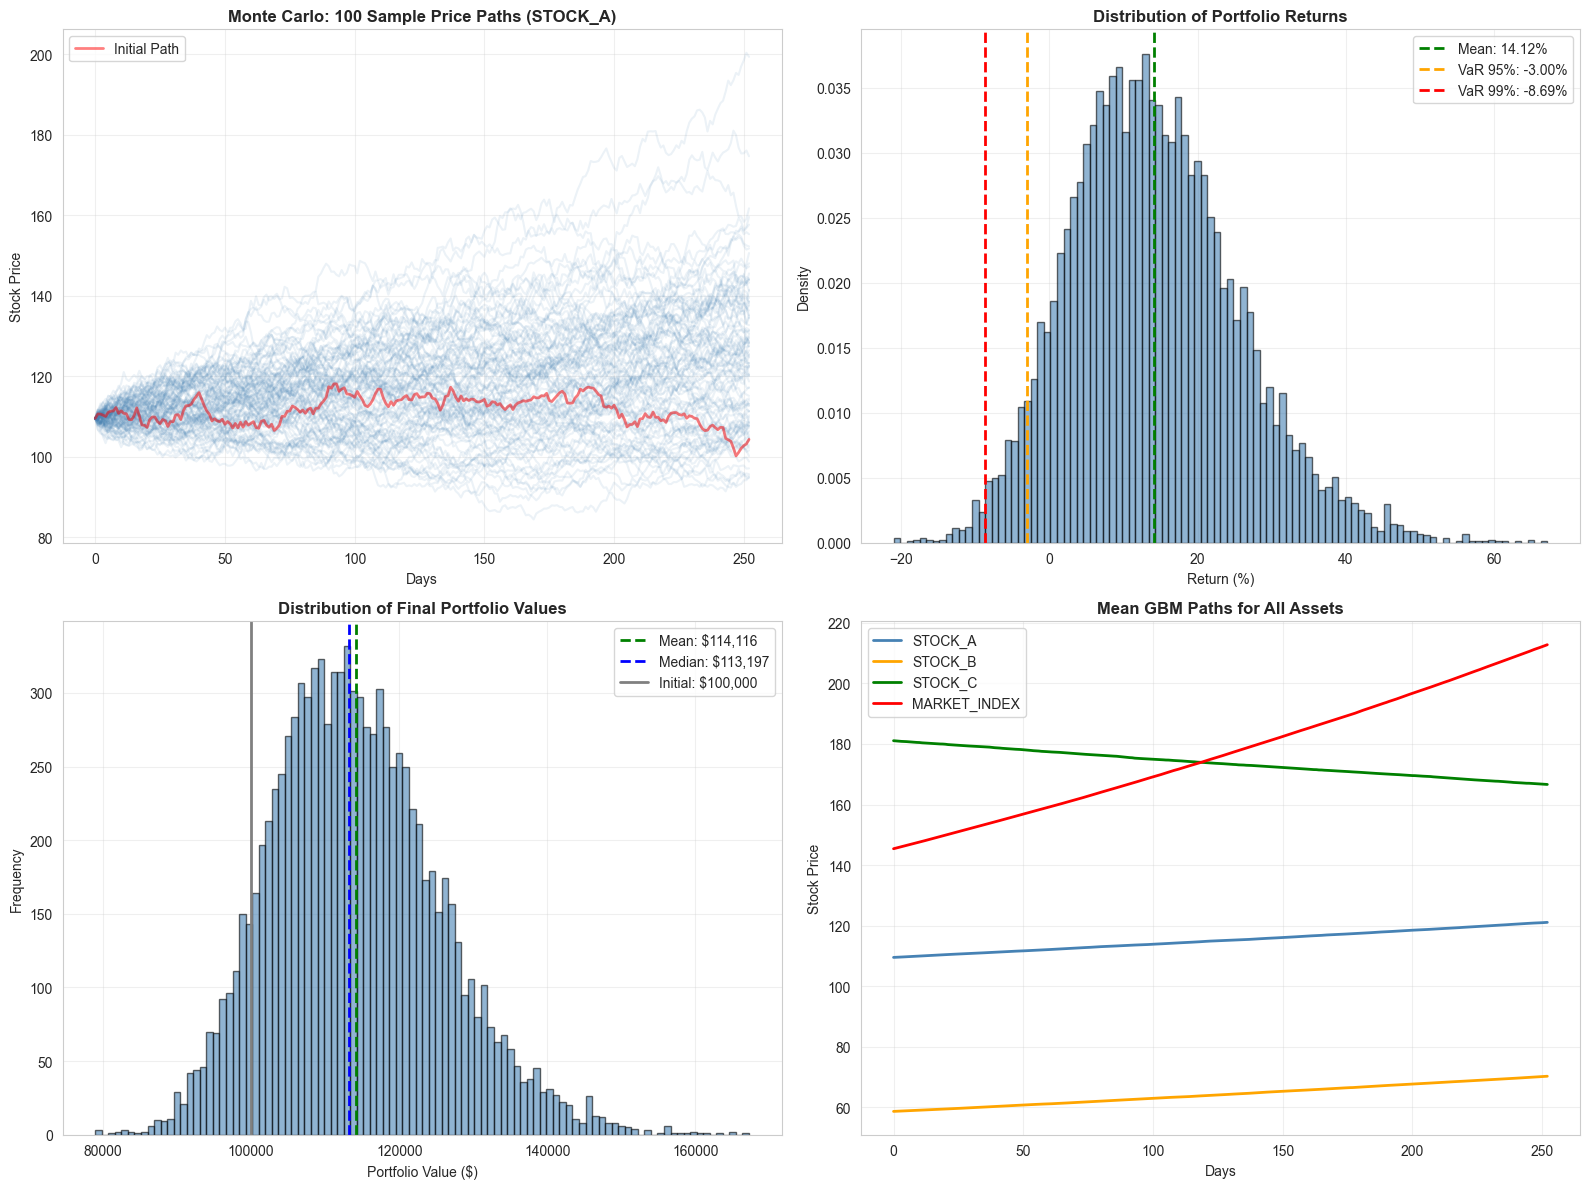


✓ Monte Carlo simulation complete!
✓ This analysis provides probability distributions for portfolio outcomes


In [10]:
# Monte Carlo Simulation using GBM
n_simulations = 10000
n_future_days = 252  # 1 year forward

# Portfolio parameters
portfolio_weights = np.array([0.3, 0.4, 0.2, 0.1])  # Weight for [STOCK_A, STOCK_B, STOCK_C, MARKET_INDEX]
initial_portfolio_value = 100000

# Extract parameters from historical data
asset_names = ['STOCK_A', 'STOCK_B', 'STOCK_C', 'MARKET_INDEX']
mus = {}
sigmas = {}
for asset in asset_names:
    mus[asset] = df_returns[asset].mean() * 252  # Annualized
    sigmas[asset] = df_returns[asset].std() * np.sqrt(252)  # Annualized

# Monte Carlo simulation
def simulate_gbm(S0, mu, sigma, T, n_steps, n_sims):
    """Simulate GBM paths"""
    dt = T / n_steps
    paths = np.zeros((n_steps + 1, n_sims))
    paths[0] = S0
    
    for i in range(1, n_steps + 1):
        Z = np.random.standard_normal(n_sims)
        paths[i] = paths[i-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    
    return paths

# Run simulations for each asset
simulated_prices = {}
for asset in asset_names:
    S0 = df_prices[asset].iloc[-1]
    mu = mus[asset]
    sigma = sigmas[asset]
    simulated_prices[asset] = simulate_gbm(S0, mu, sigma, 1.0, n_future_days, n_simulations)

# Calculate portfolio values
portfolio_future_values = np.zeros(n_simulations)
for idx, asset in enumerate(asset_names):
    final_prices = simulated_prices[asset][-1, :]
    initial_prices = simulated_prices[asset][0, 0]
    asset_returns = (final_prices - initial_prices) / initial_prices
    portfolio_future_values += portfolio_weights[idx] * asset_returns * initial_portfolio_value

total_portfolio_future_values = initial_portfolio_value * (1 + portfolio_future_values / initial_portfolio_value)

# Analysis
portfolio_return_pct = (portfolio_future_values / initial_portfolio_value) * 100
final_value_mean = np.mean(total_portfolio_future_values)
final_value_median = np.median(total_portfolio_future_values)
final_value_std = np.std(total_portfolio_future_values)
var_95 = np.percentile(portfolio_return_pct, 5)
var_99 = np.percentile(portfolio_return_pct, 1)

print("=" * 80)
print("MONTE CARLO SIMULATION RESULTS (10,000 paths, 1-year forecast)")
print("=" * 80)
print(f"Initial Portfolio Value: ${initial_portfolio_value:,.2f}")
print(f"Mean Final Value: ${final_value_mean:,.2f}")
print(f"Median Final Value: ${final_value_median:,.2f}")
print(f"Std Dev of Final Value: ${final_value_std:,.2f}")
print(f"\nPortfolio Return Statistics:")
print(f"Mean Return: {np.mean(portfolio_return_pct):.2f}%")
print(f"Median Return: {np.median(portfolio_return_pct):.2f}%")
print(f"Std Dev of Return: {np.std(portfolio_return_pct):.2f}%")
print(f"VaR (95%): {var_95:.2f}%")
print(f"VaR (99%): {var_99:.2f}%")
print(f"\n5th Percentile Value: ${np.percentile(total_portfolio_future_values, 5):,.2f}")
print(f"95th Percentile Value: ${np.percentile(total_portfolio_future_values, 95):,.2f}")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Sample price paths
ax = axes[0, 0]
for i in range(100):  # Plot 100 sample paths
    ax.plot(simulated_prices['STOCK_A'][:, i], alpha=0.1, color='steelblue')
ax.plot(simulated_prices['STOCK_A'][:, 0], alpha=0.5, color='red', linewidth=2, label='Initial Path')
ax.set_title('Monte Carlo: 100 Sample Price Paths (STOCK_A)', fontsize=12, fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Stock Price')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Distribution of portfolio returns
ax = axes[0, 1]
ax.hist(portfolio_return_pct, bins=100, alpha=0.6, color='steelblue', edgecolor='black', density=True)
ax.axvline(np.mean(portfolio_return_pct), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(portfolio_return_pct):.2f}%')
ax.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'VaR 95%: {var_95:.2f}%')
ax.axvline(var_99, color='red', linestyle='--', linewidth=2, label=f'VaR 99%: {var_99:.2f}%')
ax.set_title('Distribution of Portfolio Returns', fontsize=12, fontweight='bold')
ax.set_xlabel('Return (%)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Distribution of final portfolio values
ax = axes[1, 0]
ax.hist(total_portfolio_future_values, bins=100, alpha=0.6, color='steelblue', edgecolor='black')
ax.axvline(final_value_mean, color='green', linestyle='--', linewidth=2, label=f'Mean: ${final_value_mean:,.0f}')
ax.axvline(final_value_median, color='blue', linestyle='--', linewidth=2, label=f'Median: ${final_value_median:,.0f}')
ax.axvline(initial_portfolio_value, color='gray', linestyle='-', linewidth=2, label=f'Initial: ${initial_portfolio_value:,.0f}')
ax.set_title('Distribution of Final Portfolio Values', fontsize=12, fontweight='bold')
ax.set_xlabel('Portfolio Value ($)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Price paths for all assets
ax = axes[1, 1]
colors = ['steelblue', 'orange', 'green', 'red']
for idx, asset in enumerate(asset_names):
    mean_path = np.mean(simulated_prices[asset], axis=1)
    ax.plot(mean_path, label=asset, color=colors[idx], linewidth=2)
ax.set_title('Mean GBM Paths for All Assets', fontsize=12, fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Stock Price')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Monte Carlo simulation complete!")
print("✓ This analysis provides probability distributions for portfolio outcomes")

## Summary

Congratulations on making it through! Here is everything you covered:

| # | Concept | Key Takeaway |
|---|---------|-------------|
| 1 | **Data Generation (GBM)** | Synthetic price paths mimic real markets; used for stress-testing and model calibration |
| 2 | **Descriptive Statistics** | Mean, std, skew, kurtosis — the first things every risk manager checks on a new dataset |
| 3 | **Normality Tests** | Real returns are NOT normal — fat tails and negative skew mean parametric VaR underestimates losses |
| 4 | **Rolling Volatility** | Volatility is not constant; it clusters and spikes during market stress |
| **5** | **Variance vs Covariance** | Variance measures individual risk; covariance captures how assets interact — the interaction term in the portfolio variance formula is why diversification works |
| 6 | **Correlation & Covariance Matrix** | Correlation normalises covariance to [−1, +1]; the full matrix is the direct input to Markowitz optimisation |
| 7 | **Value at Risk (VaR) & ES** | VaR asks "how bad on a bad day?"; ES asks "how bad when VaR is breached?" — regulators now prefer ES |
| 8 | **Beta & CAPM** | Beta separates market (systematic) risk from company-specific (idiosyncratic) risk; only systematic risk is priced |
| 9 | **Time Series & Autocorrelation** | Prices are non-stationary (use returns, not prices!); squared-return ACF detects volatility clustering → GARCH |
| 10 | **Monte Carlo Simulation** | Simulate thousands of futures to get the full probability distribution of outcomes; essential for exotic derivatives and pension planning |

---

### The Dependency Chain

```
GBM Prices
    ↓
Log Returns   ← ALWAYS use returns, not prices (stationarity!)
    ↓           ↓
Variance      Covariance    ← Individual risk vs. joint risk
    ↓           ↓
Std Dev     Correlation     ← Normalised: easy to compare any pair
    ↓           ↓
Rolling Vol  Portfolio Var  ← σ²_p = w'Σw (the full matrix equation)
    ↓
VaR / ES     Beta (CAPM)   Monte Carlo   ACF / GARCH
```

### Where to go next

- **Portfolio Optimisation**: Use the covariance matrix to build the efficient frontier (mean-variance optimisation)
- **GARCH Models**: Model time-varying volatility instead of assuming it is constant
- **Factor Models**: Fama-French 3-factor, momentum, quality — multi-factor extensions of CAPM
- **Options Pricing**: Black-Scholes uses variance (σ²) as the key input; implied vol is the market's forward estimate of σ
- **Cointegration**: When two non-stationary price series have a stationary spread — the basis of pairs trading